In [3]:
import pandas as pd
import numpy as np

In [4]:
#Positives Data Inspection
positives = pd.read_csv("../processed_data/positives.csv",  parse_dates=["DATETIME"])

positives = positives[
    [
        'DATETIME',
        'LAT',
        'LON',
        'DISTRICT',
        'TEMPERATURE',
        'PERCIPITATION',
        'WIND SPEED',
        'RAIN',
        'SNOWFALL',
        'CRIME HAPPENED',
    ]
]
positives.head()

positives.head()

,DATETIME,LAT,LON,DISTRICT,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL,CRIME HAPPENED
0,2010-02-20 13:00:00,33.9825,-118.2695,9,14.2,0.0,9.7,0.0,0.0,1
1,2010-09-12 00:00:00,33.9599,-118.3962,11,16.5,0.0,4.1,0.0,0.0,1
2,2010-08-09 15:00:00,34.0224,-118.2524,9,25.5,0.0,11.5,0.0,0.0,1
3,2010-01-05 01:00:00,34.1016,-118.3295,13,8.1,0.0,7.4,0.0,0.0,1
4,2010-01-02 21:00:00,34.0387,-118.2488,14,11.6,0.0,8.5,0.0,0.0,1


In [5]:
#Negatives Data Inspection
negatives = pd.read_csv("../processed_data/negatives.csv",  parse_dates=["DATETIME"])

negatives = negatives[
    [
        'DATETIME',
        'LAT',
        'LON',
        'DISTRICT',
        'TEMPERATURE',
        'PERCIPITATION',
        'WIND SPEED',
        'RAIN',
        'SNOWFALL',
        'CRIME HAPPENED',
    ]
]

negatives.head()

,DATETIME,LAT,LON,DISTRICT,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL,CRIME HAPPENED
0,2010-02-20 21:00:00,34.208139,-118.545744,3,9.2,0.1,3.9,0.1,0.0,0
1,2010-09-12 13:00:00,34.056041,-118.533834,11,27.5,0.0,14.0,0.0,0.0,0
2,2010-08-09 20:00:00,34.114766,-118.205344,1,19.3,0.0,6.3,0.0,0.0,0
3,2010-01-05 14:00:00,34.224166,-118.617943,12,22.9,0.0,0.8,0.0,0.0,0
4,2010-01-02 11:00:00,34.240453,-118.314017,7,19.8,0.0,9.0,0.0,0.0,0


In [6]:
# Combine datasets
dataset = pd.concat(
    [positives, negatives],
    ignore_index=True
)

In [7]:
# Shuffle
dataset = dataset.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [8]:
dataset['CRIME HAPPENED'].value_counts()

CRIME HAPPENED
1    207693
0    207693
Name: count, dtype: int64

In [9]:
dataset.head()

,DATETIME,LAT,LON,DISTRICT,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL,CRIME HAPPENED
0,2010-12-21 17:00:00,34.245000,-118.457900,7,11.4,0.0,6.5,0.0,0.0,1
1,2010-07-01 17:00:00,33.933100,-118.251100,15,25.6,0.0,10.2,0.0,0.0,1
2,2010-08-13 05:00:00,34.181888,-118.451671,6,16.5,0.0,3.5,0.0,0.0,0
3,2010-02-09 08:00:00,34.141802,-118.341154,4,8.4,0.0,4.7,0.0,0.0,0
4,2010-09-28 20:00:00,34.072200,-118.378500,5,25.1,0.0,5.2,0.0,0.0,1


In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 415386 entries, 0 to 415385
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATETIME        415386 non-null  datetime64[ns]
 1   LAT             415386 non-null  float64       
 2   LON             415386 non-null  float64       
 3   DISTRICT        415386 non-null  int64         
 4   TEMPERATURE     415344 non-null  float64       
 5   PERCIPITATION   415344 non-null  float64       
 6   WIND SPEED      415344 non-null  float64       
 7   RAIN            415344 non-null  float64       
 8   SNOWFALL        415344 non-null  float64       
 9   CRIME HAPPENED  415386 non-null  int64         
dtypes: datetime64[ns](1), float64(7), int64(2)
memory usage: 31.7 MB


In [11]:
# Change data to be able to train model - datatime separate to columns
dataset['YEAR'] = dataset['DATETIME'].dt.year
dataset['MONTH'] = dataset['DATETIME'].dt.month
dataset['DAY'] = dataset['DATETIME'].dt.day
dataset['DAY OF WEEK'] = dataset['DATETIME'].dt.dayofweek
dataset['HOUR'] = dataset['DATETIME'].dt.hour
dataset = dataset.drop(columns=['DATETIME'])

In [12]:
dataset.head()

,LAT,LON,DISTRICT,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL,CRIME HAPPENED,YEAR,MONTH,DAY,DAY OF WEEK,HOUR
0,34.245000,-118.457900,7,11.4,0.0,6.5,0.0,0.0,1,2010,12,21,1,17
1,33.933100,-118.251100,15,25.6,0.0,10.2,0.0,0.0,1,2010,7,1,3,17
2,34.181888,-118.451671,6,16.5,0.0,3.5,0.0,0.0,0,2010,8,13,4,5
3,34.141802,-118.341154,4,8.4,0.0,4.7,0.0,0.0,0,2010,2,9,1,8
4,34.072200,-118.378500,5,25.1,0.0,5.2,0.0,0.0,1,2010,9,28,1,20


In [13]:
# Earth radius in km
R = 6371

lat_rad = np.radians(dataset['LAT'])
lon_rad = np.radians(dataset['LON'])

dataset['X'] = R * np.cos(lat_rad) * np.cos(lon_rad)
dataset['Y'] = R * np.cos(lat_rad) * np.sin(lon_rad)
dataset['Z'] = R * np.sin(lat_rad)

dataset.drop(columns=['LAT', 'LON'], inplace=True)

In [14]:
dataset.head()

,DISTRICT,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL,CRIME HAPPENED,YEAR,MONTH,DAY,DAY OF WEEK,HOUR,X,Y,Z
0,7,11.4,0.0,6.5,0.0,0.0,1,2010,12,21,1,17,-2509.562849,-4630.149776,3585.170618
1,15,25.6,0.0,10.2,0.0,0.0,1,2010,7,1,3,17,-2502.035656,-4656.300394,3556.448400
2,6,16.5,0.0,3.5,0.0,0.0,0,2010,8,13,4,5,-2510.939314,-4633.891910,3579.367337
3,4,8.4,0.0,4.7,0.0,0.0,0,2010,2,9,1,8,-2503.184699,-4640.929534,3575.679016
4,5,25.1,0.0,5.2,0.0,0.0,1,2010,9,28,1,20,-2508.271802,-4643.115206,3569.270898


In [15]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)

district_encoded = encoder.fit_transform(dataset[['DISTRICT']])

# Convert to DataFrame
district_df = pd.DataFrame(
    district_encoded,
    columns=encoder.get_feature_names_out(['DISTRICT'])
)

# Drop original column and concatenate
dataset = pd.concat([dataset.drop(columns=['DISTRICT']), district_df], axis=1)

In [16]:
import numpy as np

# Hour
dataset["HOUR_sin"] = np.sin(2 * np.pi * dataset["HOUR"] / 24)
dataset["HOUR_cos"] = np.cos(2 * np.pi * dataset["HOUR"] / 24)

# Month
dataset["MONTH_sin"] = np.sin(2 * np.pi * dataset["MONTH"] / 12)
dataset["MONTH_cos"] = np.cos(2 * np.pi * dataset["MONTH"] / 12)

# Day of week
dataset["DOW_sin"] = np.sin(2 * np.pi * dataset["DAY OF WEEK"] / 7)
dataset["DOW_cos"] = np.cos(2 * np.pi * dataset["DAY OF WEEK"] / 7)

# Drop originals
dataset = dataset.drop(columns=["HOUR", "MONTH", "DAY OF WEEK"])

In [17]:
dataset.head()

,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL,CRIME HAPPENED,YEAR,DAY,X,Y,...,DISTRICT_12,DISTRICT_13,DISTRICT_14,DISTRICT_15,HOUR_sin,HOUR_cos,MONTH_sin,MONTH_cos,DOW_sin,DOW_cos
0,11.4,0.0,6.5,0.0,0.0,1,2010,21,-2509.562849,-4630.149776,...,0.0,0.0,0.0,0.0,-0.965926,-0.258819,-2.449294e-16,1.000000e+00,0.781831,0.623490
1,25.6,0.0,10.2,0.0,0.0,1,2010,1,-2502.035656,-4656.300394,...,0.0,0.0,0.0,1.0,-0.965926,-0.258819,-5.000000e-01,-8.660254e-01,0.433884,-0.900969
2,16.5,0.0,3.5,0.0,0.0,0,2010,13,-2510.939314,-4633.891910,...,0.0,0.0,0.0,0.0,0.965926,0.258819,-8.660254e-01,-5.000000e-01,-0.433884,-0.900969
3,8.4,0.0,4.7,0.0,0.0,0,2010,9,-2503.184699,-4640.929534,...,0.0,0.0,0.0,0.0,0.866025,-0.500000,8.660254e-01,5.000000e-01,0.781831,0.623490
4,25.1,0.0,5.2,0.0,0.0,1,2010,28,-2508.271802,-4643.115206,...,0.0,0.0,0.0,0.0,-0.866025,0.500000,-1.000000e+00,-1.836970e-16,0.781831,0.623490


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_to_scale = ["TEMPERATURE", "WIND SPEED", "RAIN", "SNOWFALL", "X", "Y", "Z"]
dataset[cols_to_scale] = scaler.fit_transform(dataset[cols_to_scale])

In [19]:
dataset[["PERCIPITATION", "RAIN"]].corr()

,PERCIPITATION,RAIN
PERCIPITATION,1.0,1.0
RAIN,1.0,1.0


In [20]:
dataset = dataset.drop(columns=["RAIN"]) 

In [21]:
(dataset['SNOWFALL'] != 0).sum()

42

In [22]:
dataset = dataset.drop(columns=["SNOWFALL"]) 

In [23]:
dataset.head()

,TEMPERATURE,PERCIPITATION,WIND SPEED,CRIME HAPPENED,YEAR,DAY,X,Y,Z,DISTRICT_2,...,DISTRICT_12,DISTRICT_13,DISTRICT_14,DISTRICT_15,HOUR_sin,HOUR_cos,MONTH_sin,MONTH_cos,DOW_sin,DOW_cos
0,-0.852737,0.0,-0.150363,1,2010,21,-0.198612,1.059226,1.153649,0.0,...,0.0,0.0,0.0,0.0,-0.965926,-0.258819,-2.449294e-16,1.000000e+00,0.781831,0.623490
1,1.270238,0.0,0.775883,1,2010,1,0.740723,-1.426578,-1.326069,0.0,...,0.0,0.0,0.0,1.0,-0.965926,-0.258819,-5.000000e-01,-8.660254e-01,0.433884,-0.900969
2,-0.090260,0.0,-0.901374,0,2010,13,-0.370385,0.703510,0.652626,0.0,...,0.0,0.0,0.0,0.0,0.965926,0.258819,-8.660254e-01,-5.000000e-01,-0.433884,-0.900969
3,-1.301253,0.0,-0.600969,0,2010,9,0.597331,0.034533,0.334196,0.0,...,0.0,0.0,0.0,0.0,0.866025,-0.500000,8.660254e-01,5.000000e-01,0.781831,0.623490
4,1.195485,0.0,-0.475801,1,2010,28,-0.037500,-0.173231,-0.219045,0.0,...,0.0,0.0,0.0,0.0,-0.866025,0.500000,-1.000000e+00,-1.836970e-16,0.781831,0.623490


In [24]:
dataset.columns = dataset.columns.str.replace(' ', '_')

In [25]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- Split your data ---
X = dataset.drop(columns=['CRIME_HAPPENED'])
y = dataset['CRIME_HAPPENED']

X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# 80/10/10 split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1111, random_state=42, stratify=y_train_val
)

# --- Create LightGBM datasets ---
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# --- Parameters ---
params = {
    'objective': 'binary',  #  binarna klasifikacija
    'boosting_type': 'gbdt', # Gradient Boosted Decision Trees
    'learning_rate': 0.05, # Koliko model polako uči manji-sporije uči, ali obično precizniji, veći-bržeali može da promaši, tipično:0.01–0.1
    'num_leaves': 31, # Koliko kompleksno drvo može da bude (više-hvata kompleksnije obrasce, ali overfittuje), (manje - jednostavniji model)
    'max_depth': -1, # maks dubina stabla, - 1 je da nema limita
    'feature_fraction': 0.8, # Model koristi 80% feature-a po stablu, efekat: manje overfittinga, više generalizacije
    'bagging_fraction': 0.8, # Koristi 80% podataka po iteraciji
    'bagging_freq': 5, # Radi bagging svakih 5 iteracija
    'seed': 42, # da dobijaš iste rezultate svaki put
    'metric': 'binary_logloss'  #To je način na koji model meri koliko greši tokom treninga. Ne gleda samo da li je pogodio 0 ili 1, nego koliko je bio siguran u tu odluku
}

# --- Train model ---
model = lgb.train(
    params,
    train_data,
    num_boost_round=500,          # number of iterations
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val']
)

# --- Predict ---
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

# --- Evaluate ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

[LightGBM] [Info] Number of positive: 166156, number of negative: 166156
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014399 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1477
[LightGBM] [Info] Number of data points in the train set: 332312, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy: 0.7492
Precision: 0.7225
Recall: 0.8092
F1-score: 0.7634


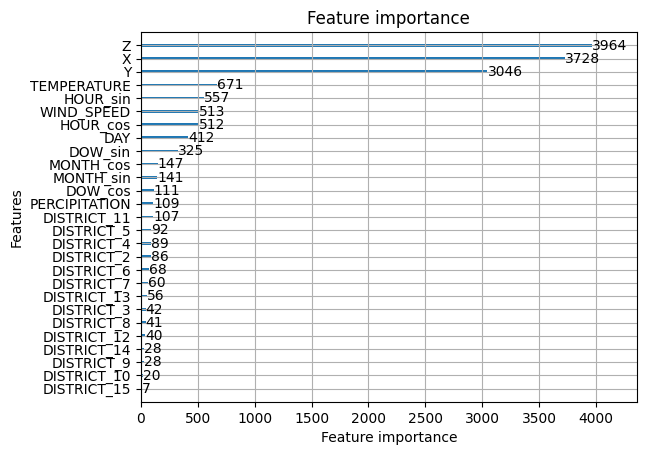

In [26]:
import matplotlib.pyplot as plt
lgb.plot_importance(model)
plt.show()

In [182]:
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb

model = lgb.LGBMClassifier()

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 100],
    'max_depth': [-1, 10, 20]
}

grid = GridSearchCV(model, param_grid, scoring='f1', cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

[LightGBM] [Info] Number of positive: 110770, number of negative: 110771
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017275 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1477
[LightGBM] [Info] Number of data points in the train set: 221541, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499998 -> initscore=-0.000009
[LightGBM] [Info] Start training from score -0.000009
[LightGBM] [Info] Number of positive: 110771, number of negative: 110770
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011148 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1480
[LightGBM] [Info] Number of data points in the train set: 221541, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500002 -> initscore=0.000009
[LightGBM] [Info] Start training from score 0.000009
[LightGB

In [26]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- Split your data ---
X = dataset.drop(columns=['CRIME_HAPPENED'])
y = dataset['CRIME_HAPPENED']

X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# 80/10/10 split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1111, random_state=42, stratify=y_train_val
)

# --- Create LightGBM datasets ---
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# --- Parameters ---
params = {
    'objective': 'binary',
    'learning_rate': 0.1,
    'num_leaves': 100,
    'max_depth': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42,
    'metric': 'binary_logloss'
}

# --- Train model ---
model = lgb.train(
    params,
    train_data,
    num_boost_round=500,          # number of iterations
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val']
)

# --- Predict ---
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

# --- Evaluate ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

[LightGBM] [Info] Number of positive: 166156, number of negative: 166156
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015494 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1477
[LightGBM] [Info] Number of data points in the train set: 332312, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy: 0.7654
Precision: 0.7423
Recall: 0.8132
F1-score: 0.7761


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

# --- Split your data ---
X = dataset.drop(columns=['CRIME_HAPPENED'])
y = dataset['CRIME_HAPPENED']

X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# (bitno za Logistic Regression) scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 80/10/10 split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1111, random_state=42, stratify=y_train_val
)

# --- Model ---
model = LogisticRegression(
   penalty='l2',
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)

# --- Train ---
model.fit(X_train, y_train)

# --- Predict ---
y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob >= 0.5).astype(int)

# --- Evaluate ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.6509
Precision: 0.6572
Recall: 0.6310
F1-score: 0.6438


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Definišemo model
model = LogisticRegression(max_iter=1000, random_state=42)

# Definišemo parametre za pretragu
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],      # snaga regularizacije
    'penalty': ['l1', 'l2'],            # tip regularizacije
    'solver': ['liblinear', 'saga']     # solver koji podržava l1 i l2
}

# Kreiramo GridSearch
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='f1',       # metrika po kojoj tražimo najbolji model
    cv=5,               # 5-fold cross-validation
    n_jobs=-1           # koristi sve CPU jezgre
)

# Fitujemo na trening podacima
grid.fit(X_train, y_train)

# Najbolji parametri i skor
print("Best params:", grid.best_params_)
print("Best F1 score:", grid.best_score_)

# Predikcija na test setu
y_pred = grid.predict(X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

# Definišemo model
model = LogisticRegression(max_iter=1000, random_state=42)

# Definišemo parametre za pretragu
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],      # snaga regularizacije
    'penalty': ['l1', 'l2'],            # tip regularizacije
    'solver': ['liblinear', 'saga']     # solver koji podržava l1 i l2
}

grid = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=10,  # try 10 random combinations
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=42
)

# Fitujemo na trening podacima
grid.fit(X_train, y_train)

# Najbolji parametri i skor
print("Best params:", grid.best_params_)
print("Best F1 score:", grid.best_score_)

# Predikcija na test setu
y_pred = grid.predict(X_test)